In [1]:
import pandas as pd
import numpy as np
import os

In [2]:


if os.path.exists("../data/processed/X_raw.npy"):
    print("Ucitavam vec obradjene podatke...")
    X = np.load("../data/processed/X_raw.npy")
else:
    print("Učitavam raw podatke...")
    data = pd.read_csv("../data/raw/GSE115469_Data.csv", index_col=0)
    X = data.to_numpy(dtype=np.float32)
    X = X.T
    del data

Ucitavam vec obradjene podatke...


In [3]:

print(X.shape)

(8444, 20007)


In [4]:
np.save("../data/processed/X_raw.npy", X)

In [5]:
X = np.load("../data/processed/X_raw.npy")

In [6]:
X[:5]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.31475955, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [7]:
variances = np.var(X, axis=0)
k = 3000
top_genes = np.argsort(variances)[-k:]

X = X[:, top_genes]

print(X.shape)


(8444, 3000)


In [8]:
from sklearn.preprocessing import StandardScaler   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
del X

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

print(X_pca.shape)

(8444, 50)


In [10]:
pca.explained_variance_ratio_.sum()

0.25720346

/home/bogdan/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


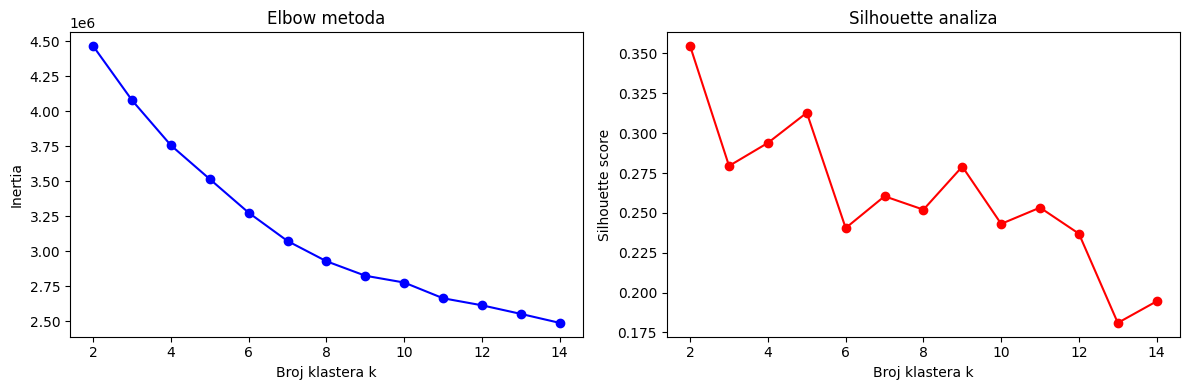

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=2000))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel("Broj klastera k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow metoda")

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel("Broj klastera k")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette analiza")

plt.tight_layout()
plt.show()

In [12]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

np.save("../data/processed/cluster_labels.npy", cluster_labels)

/home/bogdan/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


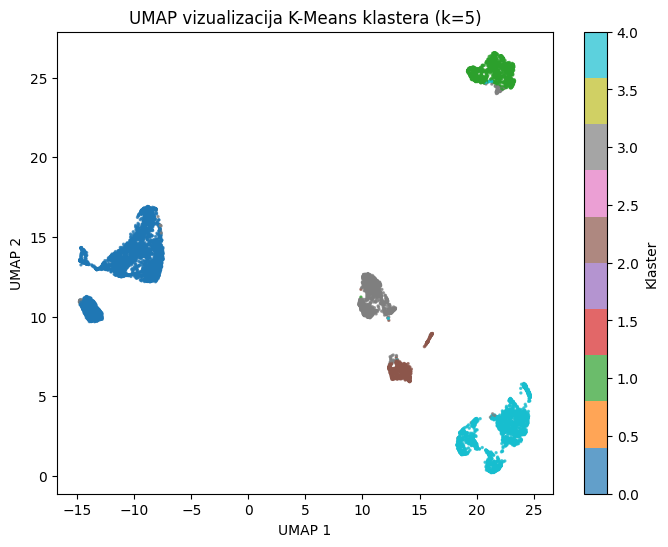

In [13]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=cluster_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Means klastera (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/X_umap.npy", X_umap)

In [14]:
X_pca.shape

(8444, 50)

In [15]:
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'complete', 'average']

for linkage in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    labels = agg.fit_predict(X_pca)
    distribution = pd.Series(labels).value_counts().sort_index().tolist()
    print(f"linkage={linkage}: raspodela={distribution}")
    
    if min(distribution) > 5:
        score = silhouette_score(X_pca, labels, sample_size=2000)
        print(f"linkage={linkage}: silhouette={score:.4f}")
    else:
        print(f"linkage={linkage}: chaining effect, silhouette nije relevantan")

linkage=ward: raspodela=[3509, 604, 1094, 1087, 2150]
linkage=ward: silhouette=0.3030
linkage=complete: raspodela=[8440, 1, 1, 1, 1]
linkage=complete: chaining effect, silhouette nije relevantan
linkage=average: raspodela=[8440, 1, 1, 1, 1]
linkage=average: chaining effect, silhouette nije relevantan


In [16]:
for linkage in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    labels = agg.fit_predict(X_pca)
    print(f"\nlinkage={linkage}:")
    print(pd.Series(labels).value_counts().sort_index())


linkage=ward:
0    3509
1     604
2    1094
3    1087
4    2150
Name: count, dtype: int64

linkage=complete:
0    8440
1       1
2       1
3       1
4       1
Name: count, dtype: int64

linkage=average:
0    8440
1       1
2       1
3       1
4       1
Name: count, dtype: int64


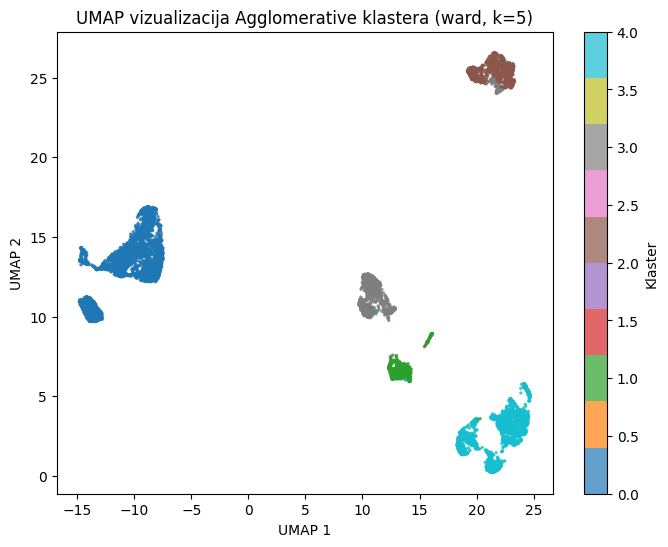

In [17]:
agg_final = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=agg_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija Agglomerative klastera (ward, k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/agg_labels.npy", agg_labels)

In [18]:
X_raw = np.load("../data/processed/X_raw.npy")
print(X_raw.shape)

(8444, 20007)


In [19]:
def prepare_and_cluster(X, n_gens, use_pca=True, k=5):
    
    variances = np.var(X, axis=0)
    top_genes = np.argsort(variances)[-n_gens:]
    X_sel = X[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
        name = f"Top{n_gens}_PCA"
    else:
        X_final = X_scaled
        name = f"Top{n_gens}_bezPCA"
    
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    print(f"{name}: silhouette={score:.4f}")
    return name, score, labels

In [20]:
results = {}

for n_genes in [500, 1000, 3000]:
    name, score, labels = prepare_and_cluster(X_raw, n_genes, use_pca=True)
    results[name] = score

for n_genes in [500, 3000]:
    name, score, labels = prepare_and_cluster(X_raw, n_genes, use_pca=False)
    results[name] = score

print("\n=== COMPARISON ===")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.1891
Top1000_PCA: silhouette=0.1837
Top3000_PCA: silhouette=0.3109
Top500_bezPCA: silhouette=0.1222
Top3000_bezPCA: silhouette=-0.0031

=== COMPARISON ===
Top3000_PCA: 0.3109
Top500_PCA: 0.1891
Top1000_PCA: 0.1837
Top500_bezPCA: 0.1222
Top3000_bezPCA: -0.0031


In [21]:
from sklearn.cluster import BisectingKMeans

configs = [
    ("Top500_PCA", 500, True),
    ("Top3000_PCA", 3000, True),
    ("Top3000_noPCA", 3000, False),
]

bisect_results = {}

for name, n_genes, use_pca in configs:
    variances = np.var(X_raw, axis=0)
    top_genes = np.argsort(variances)[-n_genes:]
    X_sel = X_raw[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
    else:
        X_final = X_scaled
    
    model = BisectingKMeans(n_clusters=5, random_state=42)
    labels = model.fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    bisect_results[name] = score
    print(f"{name}: silhouette={score:.4f}")

print("\n=== BISECTING KMEANS COMPARISON ===")
for name, score in sorted(bisect_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.1615
Top3000_PCA: silhouette=0.2823
Top3000_noPCA: silhouette=0.0310

=== BISECTING KMEANS COMPARISON ===
Top3000_PCA: 0.2823
Top500_PCA: 0.1615
Top3000_noPCA: 0.0310


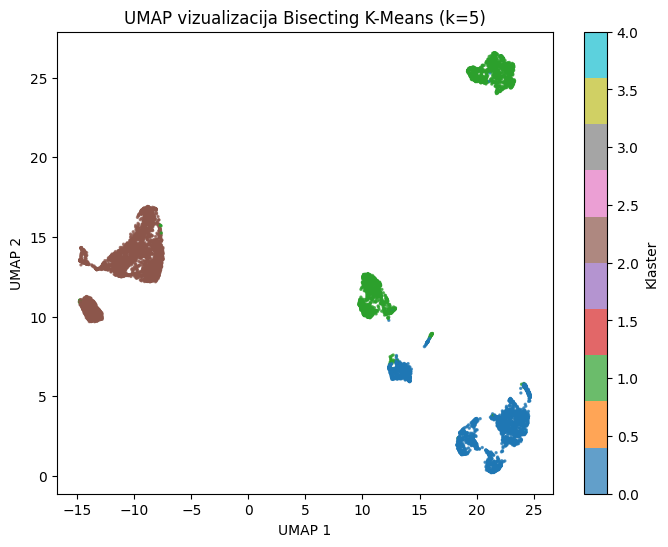

In [22]:
variances = np.var(X_raw, axis=0)
top_genes = np.argsort(variances)[-3000:]
X_sel = X_raw[:, top_genes]
X_scaled_bisect = StandardScaler().fit_transform(X_sel).astype(np.float32)
X_pca_bisect = PCA(n_components=50, random_state=42).fit_transform(X_scaled_bisect).astype(np.float32)

bisect_final = BisectingKMeans(n_clusters=5, random_state=42)
bisect_labels = bisect_final.fit_predict(X_pca_bisect)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=bisect_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija Bisecting K-Means (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/bisect_labels.npy", bisect_labels)

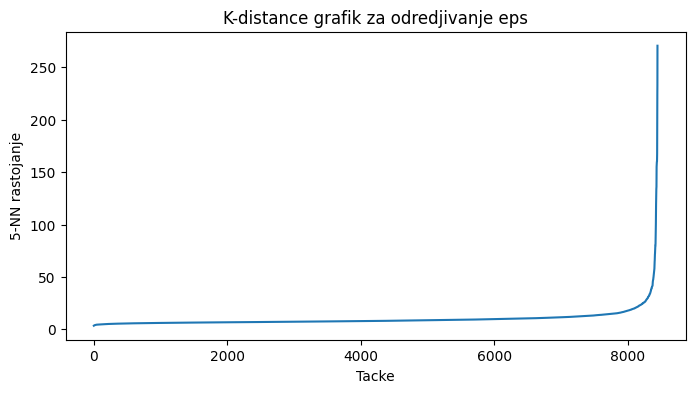

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel("Tacke")
plt.ylabel("5-NN rastojanje")
plt.title("K-distance grafik za odredjivanje eps")
plt.show()

In [24]:
for eps in [3, 5, 8, 10, 15]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print(f"eps={eps}: klastera={n_clusters}, noise={n_noise}, noise%={n_noise/len(labels)*100:.1f}%")

eps=3: klastera=0, noise=8444, noise%=100.0%
eps=5: klastera=14, noise=8115, noise%=96.1%
eps=8: klastera=5, noise=3454, noise%=40.9%
eps=10: klastera=3, noise=1754, noise%=20.8%
eps=15: klastera=3, noise=541, noise%=6.4%


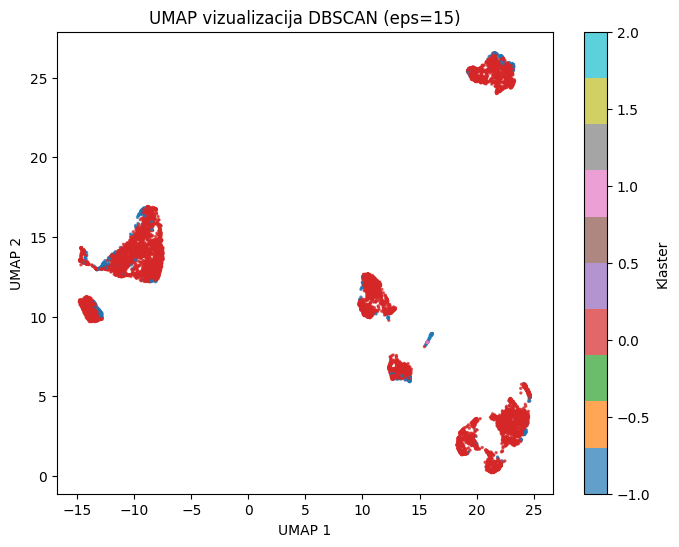

In [25]:
db_final = DBSCAN(eps=15, min_samples=5)
db_labels = db_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=db_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija DBSCAN (eps=15)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/db_labels.npy", db_labels)

In [26]:
mask = db_labels != -1
score = silhouette_score(X_pca[mask], db_labels[mask], sample_size=2000)
print(f"DBSCAN silhouette (bez noise): {score:.4f}")
print(f"Noise tačke: {np.sum(~mask)} ({np.sum(~mask)/len(db_labels)*100:.1f}%)")

DBSCAN silhouette (bez noise): 0.3278
Noise tačke: 541 (6.4%)


In [27]:
from sklearn_extra.cluster import KMedoids

configs = [
    ("Top500_PCA", 500, True),
    ("Top3000_PCA", 3000, True),
    ("Top3000_noPCA", 3000, False),
]

kmed_results = {}

for name, n_genes, use_pca in configs:
    variances = np.var(X_raw, axis=0)
    top_genes = np.argsort(variances)[-n_genes:]
    X_sel = X_raw[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
    else:
        X_final = X_scaled
    
    model = KMedoids(n_clusters=5, random_state=42)
    labels = model.fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    kmed_results[name] = score
    print(f"{name}: silhouette={score:.4f}")

print("\n=== KMEDOIDS COMPARISON ===")
for name, score in sorted(kmed_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.2406
Top3000_PCA: silhouette=0.1574
Top3000_noPCA: silhouette=-0.0290

=== KMEDOIDS COMPARISON ===
Top500_PCA: 0.2406
Top3000_PCA: 0.1574
Top3000_noPCA: -0.0290


/home/bogdan/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


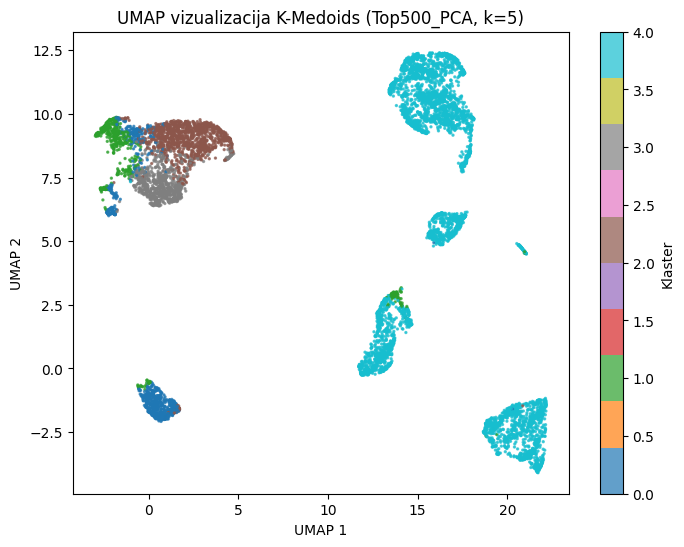

In [28]:
variances = np.var(X_raw, axis=0)
top_genes = np.argsort(variances)[-500:]
X_sel = X_raw[:, top_genes]
X_scaled_kmed = StandardScaler().fit_transform(X_sel).astype(np.float32)
X_pca_kmed = PCA(n_components=50, random_state=42).fit_transform(X_scaled_kmed).astype(np.float32)

kmed_final = KMedoids(n_clusters=5, random_state=42)
kmed_labels = kmed_final.fit_predict(X_pca_kmed)

X_umap_500 = umap.UMAP(n_components=2, random_state=42).fit_transform(X_pca_kmed)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap_500[:, 0], X_umap_500[:, 1],
                      c=kmed_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Medoids (Top500_PCA, k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

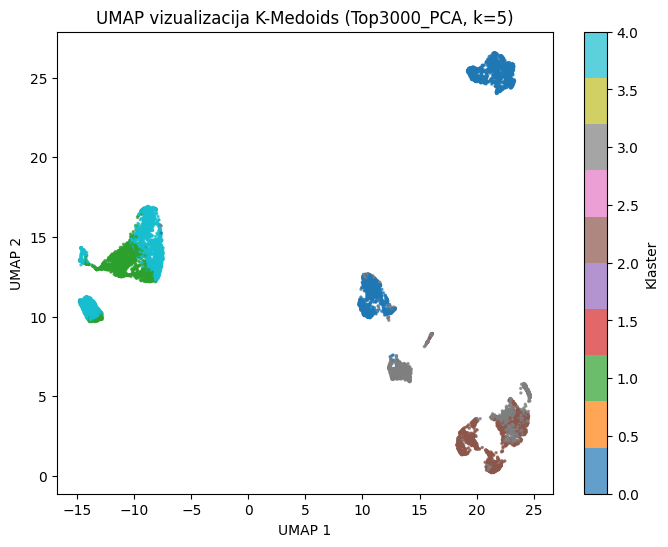

In [29]:
kmed_final = KMedoids(n_clusters=5, random_state=42)
kmed_labels = kmed_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=kmed_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Medoids (Top3000_PCA, k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/kmed_labels.npy", kmed_labels)

In [30]:
X_binary = (X_scaled > 0).astype(bool)
print(f"Prosečan broj eksprimiranih gena po ćeliji: {X_binary.sum(axis=1).mean():.0f} od {X_binary.shape[1]}")

Prosečan broj eksprimiranih gena po ćeliji: 727 od 3000


In [31]:
for i in range(5):
    n_cells = np.sum(cluster_labels == i)
    print(f"Klaster {i}: {n_cells} celija")

Klaster 0: 3480 celija
Klaster 1: 1133 celija
Klaster 2: 585 celija
Klaster 3: 1101 celija
Klaster 4: 2145 celija


In [32]:
gene_names_all = np.load("../data/processed/gene_names.npy", allow_pickle=True)

variances = np.var(X_raw, axis=0)
top_genes = np.argsort(variances)[-3000:]
gene_names = gene_names_all[top_genes]

print(gene_names.shape) 

(3000,)


In [33]:
N_GENES_ASSOC = 12
variances = np.var(X_raw, axis=0)
top_genes_assoc = np.argsort(variances)[-N_GENES_ASSOC:]
X_assoc = X_raw[:, top_genes_assoc]
gene_names_assoc = gene_names_all[top_genes_assoc]

X_binary = (X_assoc > 0).astype(bool)
print(X_binary.shape) 

(8444, 12)


In [34]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd



for cluster_id in range(5):
    print(f"\n=== KLASTER {cluster_id} ===")
    
    mask = cluster_labels == cluster_id
    X_cluster = X_binary[mask]
    
    df_cluster = pd.DataFrame(X_cluster, columns=gene_names_assoc)
    
    frequent_items = apriori(df_cluster, min_support=0.7, use_colnames=True, low_memory=True)
    
    if len(frequent_items) == 0:
        print("Nema čestih skupova sa ovim pragom")
        continue
    
    rules = association_rules(frequent_items, metric="confidence", min_threshold=0.8)
    rules = rules.sort_values("lift", ascending=False)
    
    print(f"Čestih skupova: {len(frequent_items)}")
    print(f"Pravila: {len(rules)}")
    print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(5).to_string())


=== KLASTER 0 ===


/home/bogdan/.local/lib/python3.12/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


Čestih skupova: 4095
Pravila: 523250
                                                    antecedents                                    consequents   support  confidence     lift
329286          frozenset({FGA, SAA1, APOA2, APOC3, HP, APOC1})             frozenset({SERPINA1, SAA2, APOA1})  0.972989    0.979462  1.00133
444715            frozenset({FGA, SAA1, ALB, APOA2, HP, APOC1})      frozenset({SERPINA1, SAA2, APOC3, APOA1})  0.972989    0.979462  1.00133
444712      frozenset({FGA, SAA1, ALB, APOA2, SERPINA1, APOC1})            frozenset({SAA2, HP, APOC3, APOA1})  0.972989    0.979462  1.00133
444916                frozenset({FGA, SAA1, ALB, APOA2, APOC1})  frozenset({APOC3, APOA1, SERPINA1, SAA2, HP})  0.972989    0.979462  1.00133
325679  frozenset({FGA, SAA1, ALB, APOA2, SERPINA1, HP, APOC1})                       frozenset({SAA2, APOA1})  0.972989    0.979462  1.00133

=== KLASTER 1 ===
Čestih skupova: 39
Pravila: 101
                    antecedents                  consequents

In [35]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import pandas as pd
import time

print("=" * 60)
print("FP-GROWTH ALGORITAM")
print("=" * 60)

fp_results = {}

for cluster_id in range(5):
    print(f"\n=== KLASTER {cluster_id} ===")

    mask = cluster_labels == cluster_id
    X_cluster = X_binary[mask]

    df_cluster = pd.DataFrame(X_cluster, columns=gene_names_assoc)

    t0 = time.time()
    frequent_items = fpgrowth(df_cluster, min_support=0.7, use_colnames=True)
    t1 = time.time()

    if len(frequent_items) == 0:
        print("Nema cestih skupova sa ovim pragom")
        continue

    rules = association_rules(frequent_items, metric="confidence", min_threshold=0.8)
    rules = rules.sort_values("lift", ascending=False)

    fp_results[cluster_id] = {
        "frequent_items": frequent_items,
        "rules": rules,
        "time_sec": round(t1 - t0, 3)
    }

    print(f"Cestih skupova : {len(frequent_items)}")
    print(f"Pravila        : {len(rules)}")
    print(f"Vreme (FP-Growth): {t1 - t0:.3f}s")
    print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(5).to_string())

print("\n" + "=" * 60)
print("Sumarni pregled po klasterima:")
print(f"{'Klaster':<10} {'Cestih skupova':<18} {'Pravila':<12} {'Vreme (s)'}")
print("-" * 55)
for cid, res in fp_results.items():
    print(f"{cid:<10} {len(res['frequent_items']):<18} {len(res['rules']):<12} {res['time_sec']}")

FP-GROWTH ALGORITAM

=== KLASTER 0 ===
Cestih skupova : 4095
Pravila        : 523250
Vreme (FP-Growth): 0.029s
                                            antecedents                                  consequents   support  confidence     lift
146043  frozenset({FGA, SAA1, APOA2, APOC3, HP, APOC1})                     frozenset({SAA2, APOA1})  0.972989    0.979462  1.00133
141363      frozenset({FGA, SAA1, APOA2, APOC3, APOC1})                     frozenset({SAA2, APOA1})  0.972989    0.979462  1.00133
141385             frozenset({APOC1, FGA, APOA2, SAA1})              frozenset({SAA2, APOC3, APOA1})  0.972989    0.979462  1.00133
155048           frozenset({SERPINA1, SAA2, HP, APOA1})  frozenset({FGA, SAA1, APOA2, APOC3, APOC1})  0.972989    0.994712  1.00133
155038        frozenset({SERPINA1, SAA2, APOC3, APOA1})     frozenset({FGA, SAA1, APOA2, HP, APOC1})  0.972989    0.994712  1.00133

=== KLASTER 1 ===
Cestih skupova : 39
Pravila        : 101
Vreme (FP-Growth): 0.005s
           

/home/bogdan/.local/lib/python3.12/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [ ]:
N_GENES_FP24 = 24
variances_fp24 = np.var(X_raw, axis=0)
top_genes_fp24 = np.argsort(variances_fp24)[-N_GENES_FP24:]
X_assoc_fp24 = X_raw[:, top_genes_fp24]
gene_names_fp24 = gene_names_all[top_genes_fp24]
X_binary_fp24 = (X_assoc_fp24 > 0).astype(bool)

print('=' * 60)
print(f'FP-GROWTH - {N_GENES_FP24} ATRIBUTA')
print('=' * 60)
print(f'Geni: {list(gene_names_fp24)}\n')

fp24_results = {}

for cluster_id in range(5):
    print(f'\n=== KLASTER {cluster_id} ===')

    mask = cluster_labels == cluster_id
    X_cluster = X_binary_fp24[mask]
    df_cluster = pd.DataFrame(X_cluster, columns=gene_names_fp24)

    t0 = time.time()
    frequent_items = fpgrowth(df_cluster, min_support=0.7, use_colnames=True)
    t1 = time.time()

    if len(frequent_items) == 0:
        print('Nema cestih skupova sa ovim pragom')
        fp24_results[cluster_id] = {'frequent_items': pd.DataFrame(), 'rules': pd.DataFrame(), 'time_sec': round(t1-t0, 3)}
        continue

    rules = association_rules(frequent_items, metric='confidence', min_threshold=0.8)
    rules = rules.sort_values('lift', ascending=False)

    fp24_results[cluster_id] = {
        'frequent_items': frequent_items,
        'rules': rules,
        'time_sec': round(t1 - t0, 3)
    }

    print(f'Cestih skupova : {len(frequent_items)}')
    print(f'Pravila        : {len(rules)}')
    print(f'Vreme          : {t1 - t0:.3f}s')
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5).to_string())

# --- Poredjenje 12 vs 24 atributa ---
print('\n' + '=' * 65)
print('POREDJENJE: FP-Growth 12 atributa vs 24 atributa')
print(f"{'Klaster':<10} {'Skupovi(12)':<14} {'Skupovi(24)':<14} {'Pravila(12)':<14} {'Pravila(24)':<14} {'Vreme12s':<11} {'Vreme24s'}")
print('-' * 80)
for cid in range(5):
    r12 = fp_results.get(cid, {})
    r24 = fp24_results.get(cid, {})
    s12 = len(r12.get('frequent_items', [])) if r12 else '-'
    s24 = len(r24.get('frequent_items', [])) if r24 else '-'
    p12 = len(r12.get('rules', [])) if r12 else '-'
    p24 = len(r24.get('rules', [])) if r24 else '-'
    t12 = r12.get('time_sec', '-')
    t24 = r24.get('time_sec', '-')
    print(f"{cid:<10} {str(s12):<14} {str(s24):<14} {str(p12):<14} {str(p24):<14} {str(t12):<11} {t24}")

FP-GROWTH - 24 ATRIBUTA
Geni: ['APOH', 'FGL1', 'TF', 'APOE', 'FGG', 'ORM2', 'AMBP', 'MT2A', 'MT1X', 'RBP4', 'MT1G', 'FGB', 'SERPINA1', 'SAA2', 'FGA', 'APOA1', 'SAA1', 'TTR', 'APOC1', 'ALB', 'HP', 'ORM1', 'APOA2', 'APOC3']


=== KLASTER 0 ===
